In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('PGA_Data.csv')
df = df[["player", "season", "sg_ott", "sg_app", "sg_arg", "sg_putt", "sg_total"]]
display(df)

,player,season,sg_ott,sg_app,sg_arg,sg_putt,sg_total
0,Abraham Ancer,2022,0.86,-0.08,-0.13,0.20,0.85
1,Adam Hadwin,2022,0.18,0.31,0.75,0.36,1.60
2,Anirban Lahiri,2022,0.37,-1.09,0.74,-0.56,-0.54
3,Adam Long,2022,0.80,-0.02,-1.86,-1.46,-2.54
4,Alexander Noren,2022,0.19,-1.39,-0.36,0.53,-1.04
...,...,...,...,...,...,...,...
36859,Vijay Singh,2015,NaN,NaN,NaN,NaN,NaN
36860,Whee Kim,2015,NaN,NaN,NaN,NaN,NaN
36861,William McGirt,2015,NaN,NaN,NaN,NaN,NaN
36862,Zac Blair,2015,NaN,NaN,NaN,NaN,NaN


In [15]:
def normalize(series):
    # scale to 0-1 probability
    return (series - series.min()) / (series.max() - series.min())

df["p_tee_fairway"] = normalize(df["sg_ott"])
df["p_fairway_green"] = normalize(df["sg_app"])
df["p_rough_green"] = normalize(df["sg_app"] * 0.6)   
df["p_bunker_green"] = normalize(df["sg_arg"])
df["p_green_hole"] = normalize(df["sg_putt"])


In [16]:
p_tee_fairway   = df["p_tee_fairway"].mean()
p_fairway_green = df["p_fairway_green"].mean()
p_rough_green   = df["p_rough_green"].mean()
p_bunker_green  = df["p_bunker_green"].mean()
p_green_hole    = df["p_green_hole"].mean()

In [17]:
states = ["Tee", "Fairway", "Rough", "Bunker", "Green", "Hole"]
transition_matrix = pd.DataFrame(0.0, index=states, columns=states)

# Tee
transition_matrix.loc["Tee", "Fairway"] = p_tee_fairway
transition_matrix.loc["Tee", "Rough"]   = (1 - p_tee_fairway) * 0.7
transition_matrix.loc["Tee", "Bunker"]  = (1 - p_tee_fairway) * 0.3

# Fairway
transition_matrix.loc["Fairway", "Green"] = p_fairway_green
transition_matrix.loc["Fairway", "Rough"] = (1 - p_fairway_green) * 0.6
transition_matrix.loc["Fairway", "Bunker"]= (1 - p_fairway_green) * 0.4

# Rough
transition_matrix.loc["Rough", "Green"]  = p_rough_green
transition_matrix.loc["Rough", "Rough"]  = (1 - p_rough_green) * 0.5
transition_matrix.loc["Rough", "Bunker"] = (1 - p_rough_green) * 0.5

# Bunker
transition_matrix.loc["Bunker", "Green"] = p_bunker_green
transition_matrix.loc["Bunker", "Rough"] = 1 - p_bunker_green

# Green
transition_matrix.loc["Green", "Hole"]  = p_green_hole
transition_matrix.loc["Green", "Green"] = 1 - p_green_hole

# Hole is absorbing
transition_matrix.loc["Hole", "Hole"] = 1.0

print("Transition Matrix:\n")
print(transition_matrix.round(2))

Transition Matrix:

         Tee  Fairway  Rough  Bunker  Green  Hole
Tee      0.0     0.73   0.19    0.08   0.00  0.00
Fairway  0.0     0.00   0.21    0.14   0.66  0.00
Rough    0.0     0.00   0.17    0.17   0.66  0.00
Bunker   0.0     0.00   0.33    0.00   0.67  0.00
Green    0.0     0.00   0.00    0.00   0.44  0.56
Hole     0.0     0.00   0.00    0.00   0.00  1.00


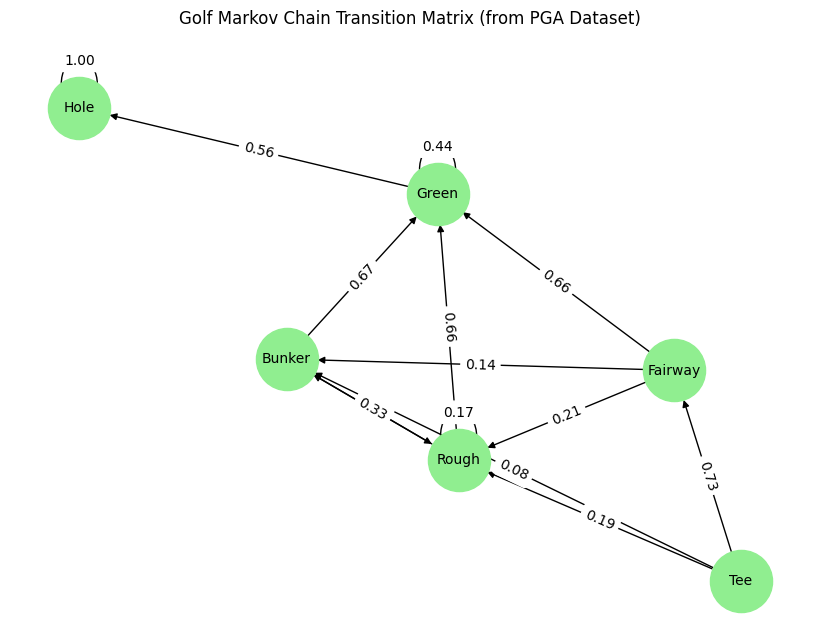

In [ ]:
import networkx as nx

G = nx.DiGraph()
for i in states:
    for j in states:
        p = transition_matrix.loc[i, j]
        if p > 0:
            G.add_edge(i, j, weight=p)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color="lightgreen", node_size=2000, font_size=10)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels={k: f"{v:.2f}" for k, v in labels.items()})
plt.title("Golf Markov Chain Transition Matrix (from PGA Dataset)")
plt.show()